# Custom CNN architecture

Processing calc patients: 100%|█████████████████████████████████████████████████████| 114/114 [00:00<00:00, 158.36it/s]



calc:
  Train patients: 527
  Val patients:   112
  Test patients:  114
  Total patients: 753
  Overlaps: train-val=0, train-test=0, val-test=0
  Image counts -> Train: 1283, Val: 326, Test: 263


Processing mass patients: 100%|█████████████████████████████████████████████████████| 135/135 [00:00<00:00, 367.20it/s]



mass:
  Train patients: 624
  Val patients:   133
  Test patients:  135
  Total patients: 892
  Overlaps: train-val=0, train-test=0, val-test=0
  Image counts -> Train: 1193, Val: 262, Test: 241
--- Shapes After Concatenation & Shuffling ---
Non-CLAHE X_train: (2476, 224, 224, 1) | y_train: (2476,)
CLAHE     X_train: (2476, 224, 224, 1)     | y_train: (2476,)
clahe
train


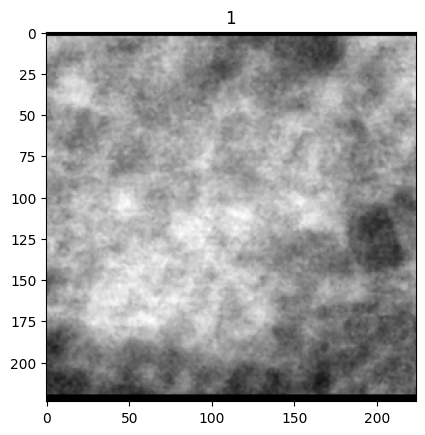

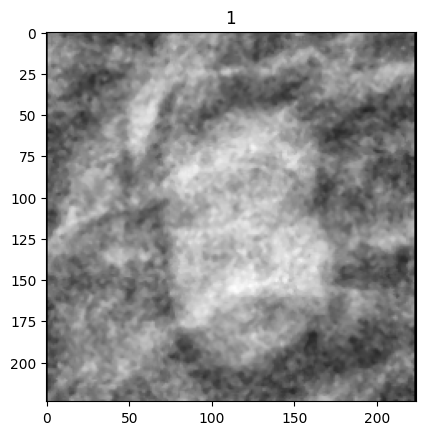

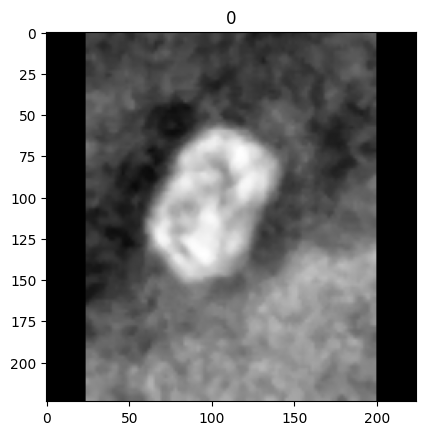

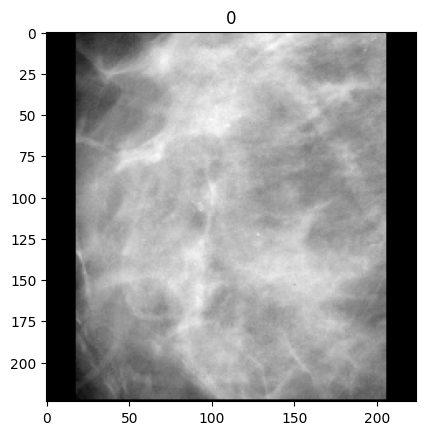

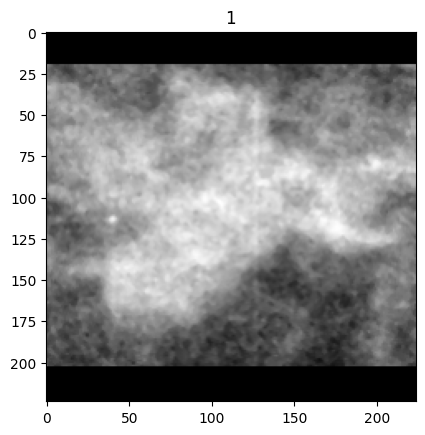

val


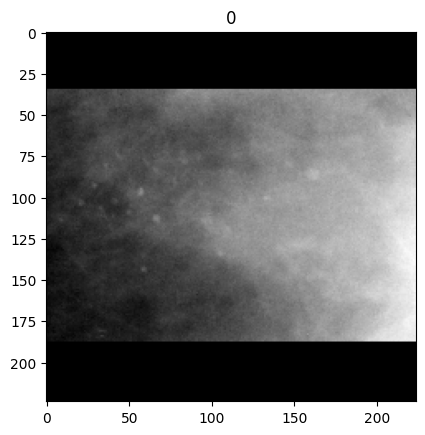

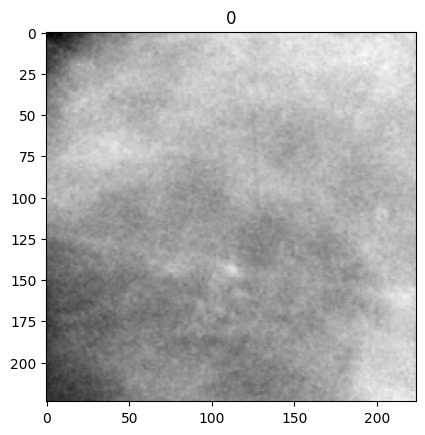

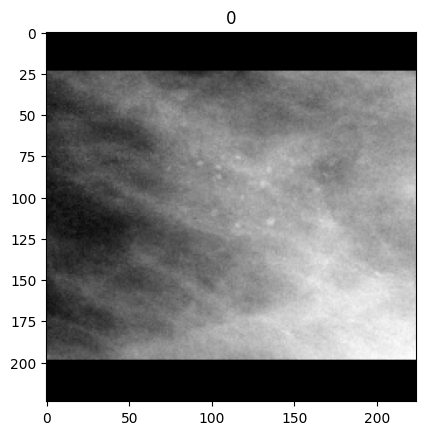

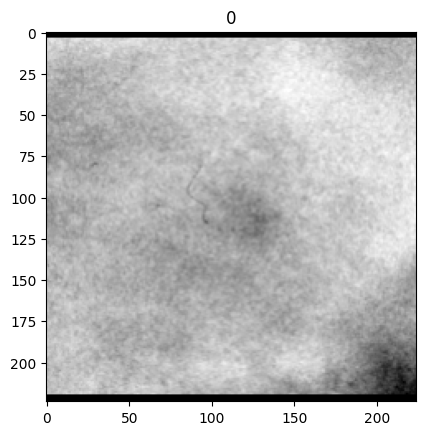

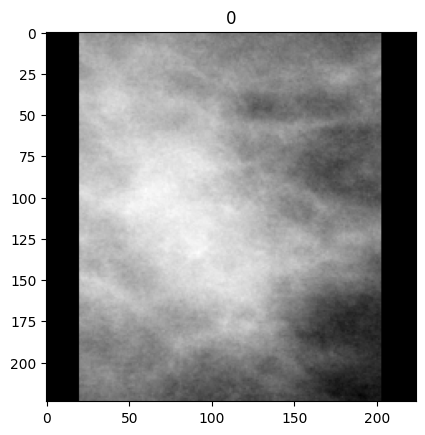

test


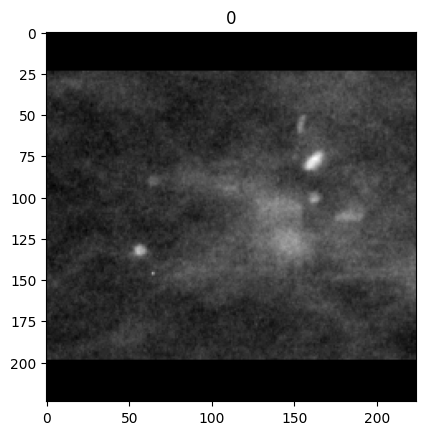

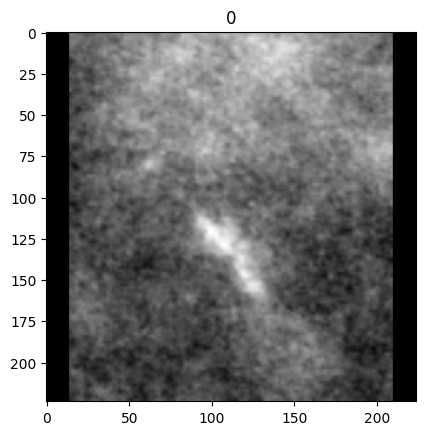

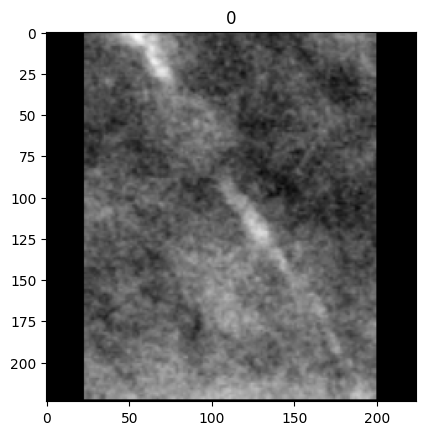

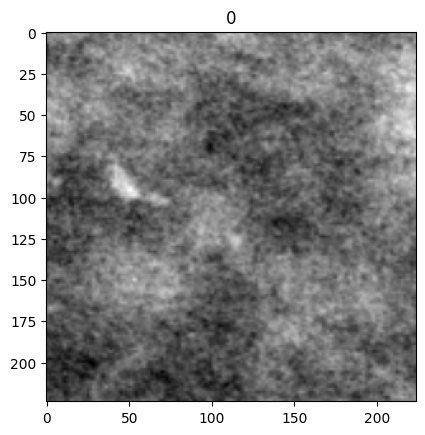

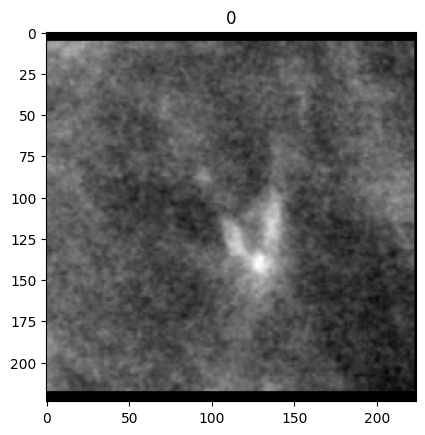

non clahe
train


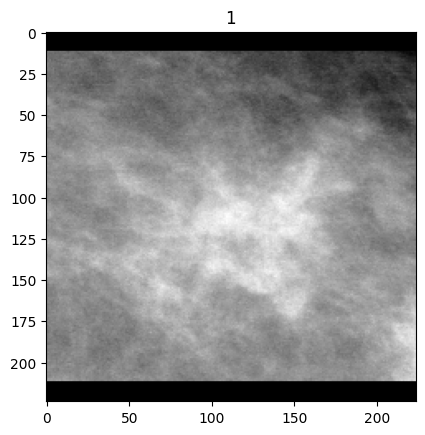

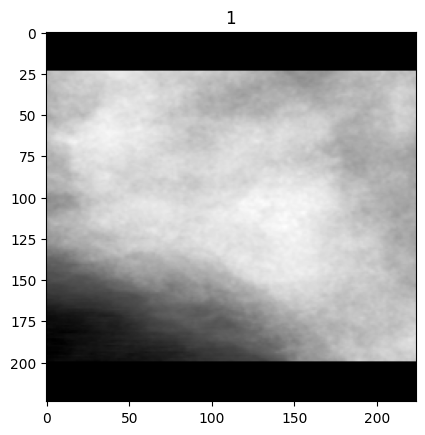

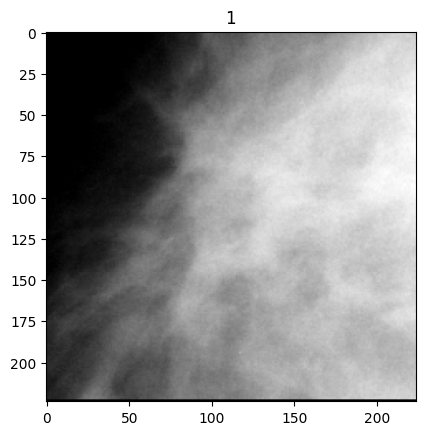

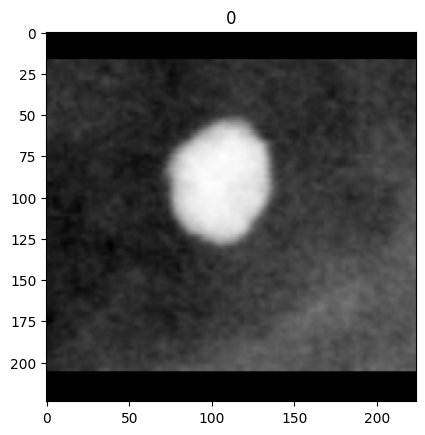

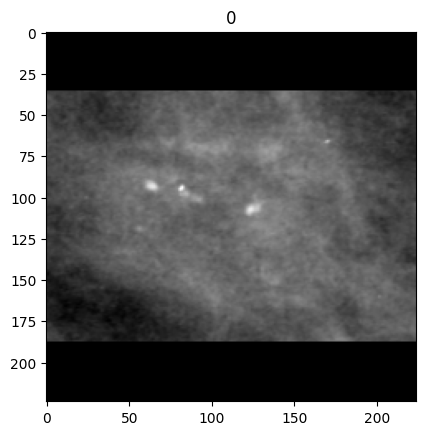

val


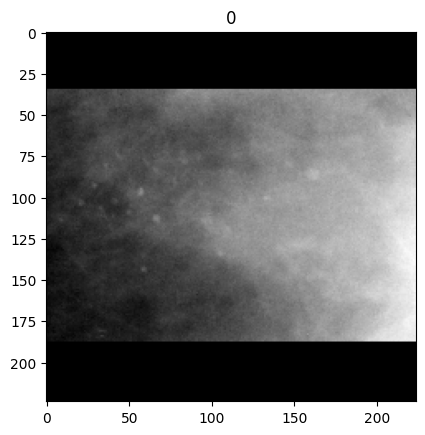

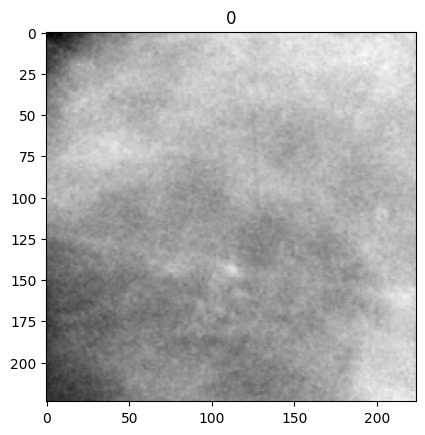

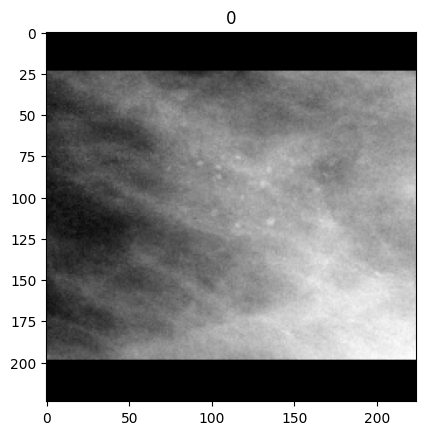

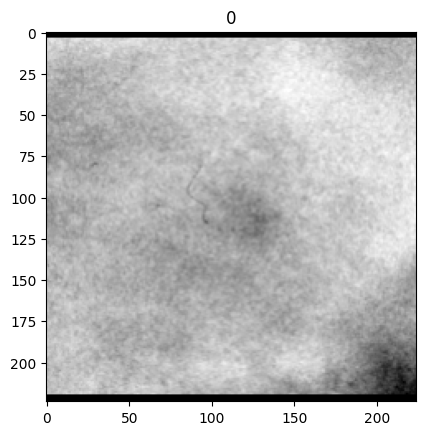

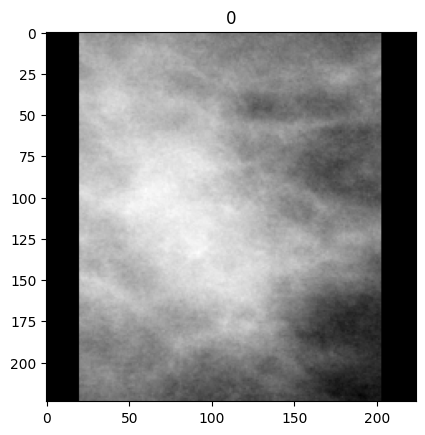

test


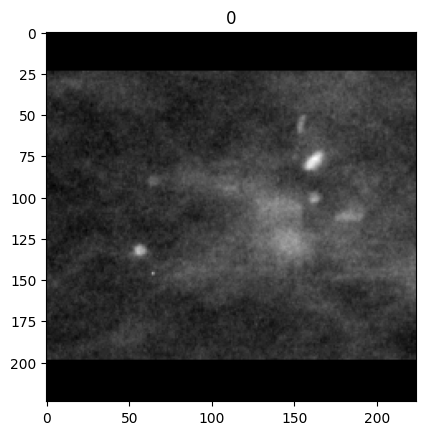

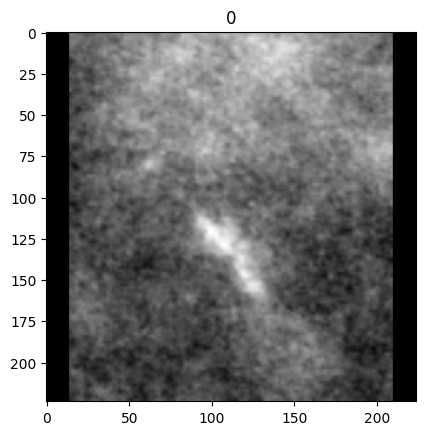

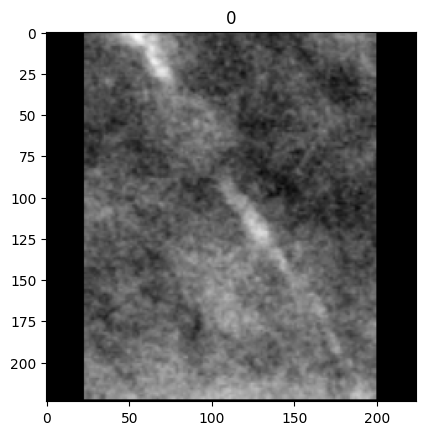

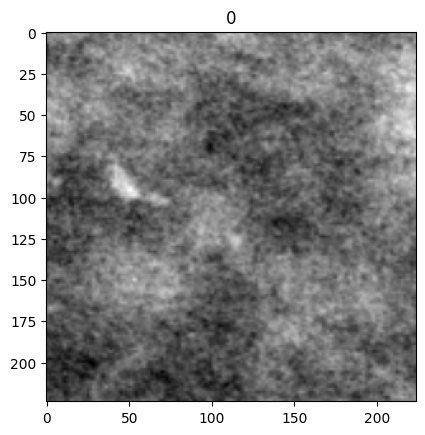

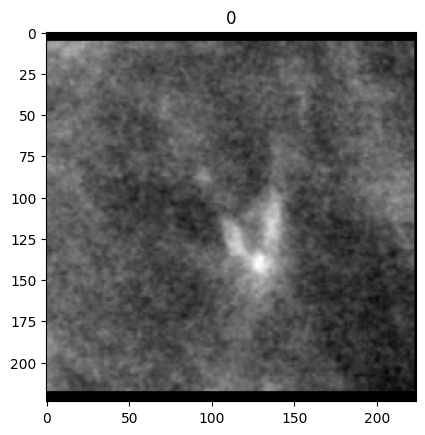

In [1]:
# Run the previous notebook to load all its classes and functions
%run cbis_ddsm_create_ROI_dataset_classification_rs2.ipynb

In [2]:
X_train = X_train_non_clahe.astype('float32') / 255.0
X_val   = X_val_non_clahe.astype('float32') / 255.0
X_test  = X_test_non_clahe.astype('float32') / 255.0

print(f"Final shapes AFTER NORMALIZATION -> X_train_non_clahe: {X_train.shape}, X_val_non: {X_val.shape}, X_test_non: {X_test.shape}")


Final shapes AFTER NORMALIZATION -> X_train_non_clahe: (2476, 224, 224, 1), X_val_non: (588, 224, 224, 1), X_test_non: (504, 224, 224, 1)


## ON-THE-FLY augmentation

In [3]:
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU, BatchNormalization, Conv2D, MaxPooling2D, Flatten,  Dropout, Activation
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import seaborn as sns
import time

data_augmentation = tf.keras.Sequential(
    [
        # 1. FLIPS (Matches 'hflip' & 'vflip')
        # Your static code chooses one or the other; this enables both possibilities.
        layers.RandomFlip(mode="horizontal_and_vertical"),

        # 2. ROTATION (Matches 'rotate' 0-90 degrees)
        # Keras factor is a fraction of 2Pi. 90 deg / 360 deg = 0.25.
        # We use a tuple (0.0, 0.25) to ensure rotation is only positive (0 to 90), 
        # matching your static "np.random.uniform(0, 90)".
        layers.RandomRotation(
            factor=(0.0, 0.25), 
            fill_mode="reflect"
        ),

        # 3. SHIFT (Matches 'shift' ±5 pixels)
        # Image size is 224. 5 / 224 ≈ 0.0223.
        layers.RandomTranslation(
            height_factor=0.0223, 
            width_factor=0.0223, 
            fill_mode="reflect"
        ),

        # 4. SCALING (Matches 'scale' 0.9 to 1.1)
        # Your static code uses a scale matrix. 
        # 0.9 is Zoom Out, 1.1 is Zoom In.
        # Keras factor represents the percentage change: ±0.1.
        layers.RandomZoom(
            height_factor=(-0.1, 0.1), 
            width_factor=(-0.1, 0.1), 
            fill_mode="reflect"
        ),

        # 5. NOISE (Matches 'noise' Normal(0, 3))
        # Note: Keras models usually process inputs normalized to [0, 1].
        # Your static noise is std=3 on [0, 255] data.
        # Equivalent on [0, 1] data is 3/255 ≈ 0.0117.
        # If your model inputs are actually 0-255, change this back to 3.0.
        layers.GaussianNoise(stddev=3.0 / 255.0),
    ],
    name="data_augmentation",
)



In [4]:
print(f"Final shapes AFTER NORMALIZATION -> y_train_non_clahe: {y_train_non_clahe.shape}")
print(f"Final shapes AFTER NORMALIZATION -> y_val_non_clahe: {y_val_non_clahe.shape}")

Final shapes AFTER NORMALIZATION -> y_train_non_clahe: (2476,)
Final shapes AFTER NORMALIZATION -> y_val_non_clahe: (588,)


In [5]:
#Apply early stopping to save time & avoid overfitting
# Early stopping
early_stop = EarlyStopping(patience=8, restore_best_weights=True,monitor='val_loss', verbose=1)


    # Model definition
model = Sequential([
        Input(shape=(224, 224, 1)),
        data_augmentation,
        Conv2D(32, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(32*2, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(32*4, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    # Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

    # Train
model.fit(
        X_train, y_train_non_clahe,
        validation_data=(X_val, y_val_non_clahe),
        epochs=60,
        batch_size=8,
        callbacks=[early_stop]
    )



Epoch 1/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 65s 205ms/step - accuracy: 0.6300 - loss: 0.6442 - val_accuracy: 0.7738 - val_loss: 0.5418
Epoch 2/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 63s 203ms/step - accuracy: 0.7310 - loss: 0.5706 - val_accuracy: 0.7398 - val_loss: 0.5105
Epoch 3/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 63s 203ms/step - accuracy: 0.7589 - loss: 0.5195 - val_accuracy: 0.7925 - val_loss: 0.4719
Epoch 4/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 64s 206ms/step - accuracy: 0.7763 - loss: 0.4847 - val_accuracy: 0.8129 - val_loss: 0.4293
Epoch 5/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 63s 205ms/step - accuracy: 0.7835 - loss: 0.4534 - val_accuracy: 0.8282 - val_loss: 0.3808
Epoch 6/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 63s 204ms/step - accuracy: 0.7973 - loss: 0.4565 - val_accuracy: 0.7908 - val_loss: 0.4184
Epoch 7/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 63s 204ms/step - accuracy: 0.7997 - loss: 0.4297 - val_accuracy: 0.8078 - val_loss: 0.3949
Epoch 8/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 64s 208ms/step - accuracy: 0.8037 - loss: 0

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step

Classification Report:
sequential
              precision    recall  f1-score   support

           0     0.8829    0.8558    0.8692       326
           1     0.8272    0.8588    0.8427       262

    accuracy                         0.8571       588
   macro avg     0.8551    0.8573    0.8559       588
weighted avg     0.8581    0.8571    0.8574       588

F2-score: 0.8572


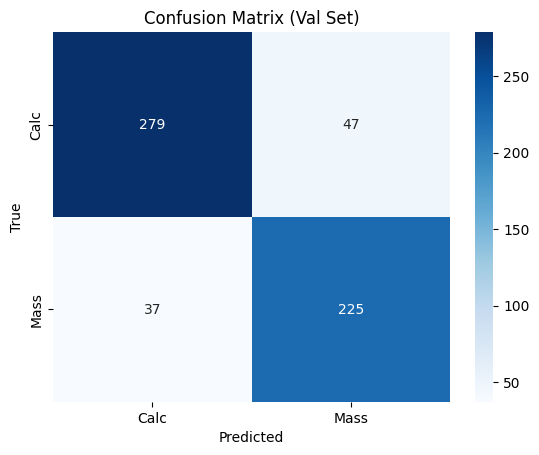

In [6]:
from sklearn.metrics import fbeta_score


# Predict probabilities
y_val_probs = model.predict(X_val)

# Convert probabilities to class labels
y_val_pred = (y_val_probs >= 0.5).astype(int).flatten()

# Classification Report (includes precision, recall, f1-score per class)
print("\nClassification Report:")
print(model.name)
print(classification_report(y_val_non_clahe, y_val_pred, digits=4))


f2_score = fbeta_score(y_val_non_clahe, y_val_pred, beta=2, average='weighted')
print("F2-score:", round(f2_score, 4))


cm = confusion_matrix(y_val_non_clahe, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Calc', 'Mass'], yticklabels=['Calc', 'Mass'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Val Set)')
plt.show()



# Explaining important conceps

### CNNs
- specialized NNs designed for grid-like data
- automatically learn spacial hierarchies of features through convolution operations
- highly effective in tasks involving visual perception

### Convolutional layer
**Convolution** is a mathematical operation where a small filter (kernel) is systematically applied across an input (such as an image) to produce a feature map that captures important local patterns like edges, textures, or more complex structures.

- **number of filters** = how many different kernels does the layer apply? So we basically get **number of filters** different feature maps.
- As we go on through the layers of the model, we may need more and more different kernels to try, because we have more intricate patterns in the images.

- **kernel_size** = what is the size of the filter/kernels, helping us to detect edges like shapes, edges etc.

- **activation** = the activation function used

### Pooling layers

A pooling layer reduces the spatial dimentions(width and height) of a feature map by summarizing regions of th input, helping to decrease computation, control overfitting, and make the network more robust to small translations

Purpose:

- downsampling: reduces the size of feature maps;
- feature preservation: keeps the most important information
- translation invariance: small changes in input data do not change the pooled output much

### Max Pooling

Helps us detect the strongest activation, e.g. what feature is the most present. This way, we can detect more proeminent patterns and also improve computations.

### Fully Connected Layers

Learn from the high-level features extracted by convolutional and pooling layers

- **dropout** - during training, turns off a percent of neurons in the Dense layer, to prevent overfitting.

### ReLU Activation
- keeps patterns of the data, also getting rid of negative values
- neurons stuck with negative inputs stop updating (gradient = 0)
- most popular in modern NNs

### LeakyReLU 
- allows a small gradient when x < 0 → avoids dying ReLU.

### Batch size
- how many training samples the network processes before updating its weights during training. It influences both the model's performance and the computational efficiency.
- some mostly used values are 32, 64, 128 ...
- I chose 32 because it puts in balance the computational resources needed and the efficiency of the model



### Adam Optimizer

Adam (short for **Adaptive Moment Estimation**) is one of the most popular and effective optimization algorithms used to train deep learning models. Adam adapts the learning rate for each parameter individually using **first** and **second moments** of the gradients:

- The **first moment** is the **mean** of the gradient (like momentum).
- The **second moment** is the **uncentered variance** of the gradient.

This helps Adam:
- Converge faster
- Handle sparse gradients
  